# **Imports** 

> Add blockquote



In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from transformers import BertTokenizerFast
from datasets import load_dataset

import numpy as np
import matplotlib.pyplot as plt
from torchmetrics import Accuracy

from tqdm import tqdm

# **Dataset**

### laod Dataset

In [8]:
from datasets import load_dataset

In [ ]:
dataset = load_dataset("fancyzhx/ag_news")

In [ ]:
dataset.save_to_disk("D:/Demis2/ag_news_dataset")

In [11]:
from datasets import load_from_disk

dataset = load_from_disk(
    r"D:\Demis2\ag_news_dataset"
)

# **Preprocessing**

In [12]:
train_valid = dataset["train"].train_test_split(test_size=0.2,seed=42)       

In [13]:
train_valid.shape

{'train': (96000, 2), 'test': (24000, 2)}

In [14]:
train_dataset = train_valid["train"]
valid_dataset = train_valid["test"]
test_dataset = dataset["test"]

In [38]:
valid_dataset.shape

(24000, 5)

In [39]:
train_dataset.shape

(96000, 5)

In [40]:
test_dataset.shape

(7600, 5)

In [34]:
train_dataset.column_names

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

In [15]:
train_dataset.shape

(96000, 2)

### Tokenization


In [16]:
from transformers import BertTokenizerFast


In [17]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

In [18]:
tokenizer("demis is the Best")

{'input_ids': [101, 27668, 2015, 2003, 1996, 2190, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

In [19]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [20]:
sent = ('demis is the best', 'its students are awsome')

In [21]:
tokenizer.convert_ids_to_tokens(101)


'[CLS]'

In [ ]:
tokenizer.convert_ids_to_tokens(102)

'[SEP]'

In [29]:
tokenizer.convert_tokens_to_ids('[ukn]')

100

### Maapping

In [30]:
train_dataset = train_dataset.map(tokenize, batched=True)
valid_dataset = valid_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)


Map: 100%|██████████| 7600/7600 [00:01<00:00, 7462.60 examples/s] 


In [35]:
train_dataset

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 96000
})

In [45]:
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
valid_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# **DataLoader**

In [46]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [42]:
x = next(iter(train_loader))

In [49]:
batch = next(iter(valid_loader))
batch

{'label': tensor([0, 1, 0, 3, 0, 3, 0, 3, 3, 2, 1, 2, 3, 0, 2, 1, 1, 2, 2, 3, 3, 2, 3, 2,
         0, 1, 3, 2, 1, 1, 3, 1]),
 'input_ids': tensor([[  101,  7269, 11498,  ...,     0,     0,     0],
         [  101,  4078, 24771,  ...,     0,     0,     0],
         [  101,  2097, 22072,  ...,     0,     0,     0],
         ...,
         [  101,  2055,  1011,  ...,     0,     0,     0],
         [  101,  4773,  2609,  ...,     0,     0,     0],
         [  101, 17137, 23278,  ...,     0,     0,     0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]])}

In [53]:
print(batch["input_ids"].shape)

torch.Size([32, 128])


In [43]:
input_ids = x['input_ids'].long()

In [44]:
input_ids

tensor([[  101,  2538,  3280,  ...,     0,     0,     0],
        [  101,  2449,  3604,  ...,     0,     0,     0],
        [  101,  5712,  1005,  ...,     0,     0,     0],
        ...,
        [  101,  9105,  1037,  ...,     0,     0,     0],
        [  101,  3103, 24669,  ...,     0,     0,     0],
        [  101, 10118, 17167,  ...,     0,     0,     0]])

In [ ]:
print(input_ids.dtype)

torch.int64


# **Model**

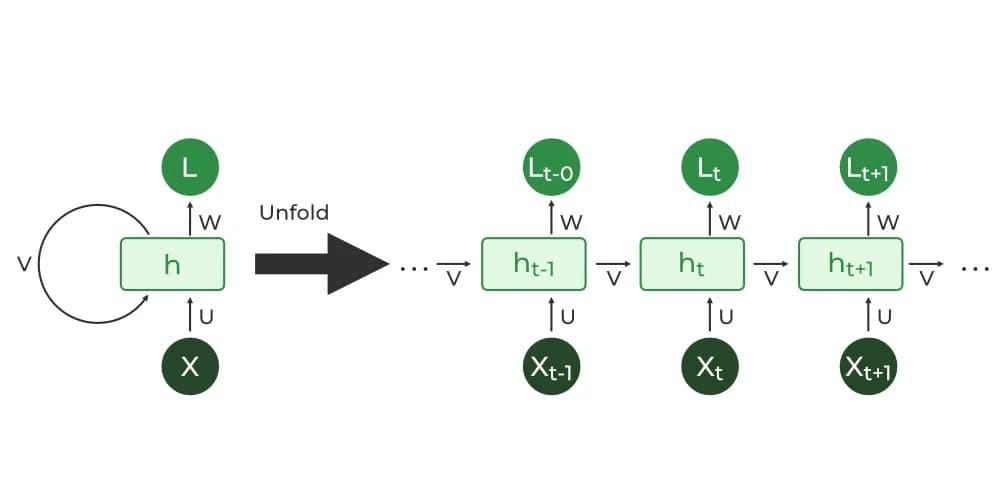

Pre_Trained Model

In [54]:
import torch.nn as nn

In [55]:
vocab_size = tokenizer.vocab_size

In [56]:
vocab_size

30522

In [57]:
embedding = nn.Embedding(30522, 128)

In [58]:
embd = embedding(input_ids)

In [59]:
embd.shape

torch.Size([32, 128, 128])

                                                    BertTokenizerFast
                                                        ↓
                                                    input_ids
                                                    [32, 128]
                                                        ↓
                                                    nn.Embedding
                                                        ↓
                                                    [32, 128, 128]
                                                        ↓
                                                        nn.RNN
                                                        ↓
                                                    [32, 128, 64]
                                                        ↓
                                                    last timestep
                                                        ↓
                                                    [32, 64]
                                                        ↓
                                                    Linear
                                                        ↓
                                                    [32, 4]

In [ ]:
class RNNModel(nn.Module):
    def __init__(self, RNN, vocab_size, input_size, hidden_size, num_layers, bidirectional, num_cls):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, input_size)
        self.rnn = RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=bidirectional,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size * (2 if bidirectional else 1), num_cls)

    def forward(self, x):
        x = self.embedding(x)
        #x = x.permute(1, 0, 2)
        outputs, _ = self.rnn(x)
        y = self.fc(outputs)
        y = y.mean(dim=0)
        return y

In [ ]:
model = RNNModel(nn.RNN, vocab_size, 32, 128, 1, True, 4)

In [ ]:
model(input_ids)

tensor([[ 0.0665,  0.0401, -0.2279,  0.1454],
        [ 0.1110,  0.0678, -0.0149,  0.0508],
        [ 0.0532,  0.0973,  0.0375, -0.0271],
        [ 0.0645, -0.0077, -0.0103,  0.0017],
        [ 0.0538,  0.0756,  0.0249, -0.0252],
        [ 0.0699,  0.0908,  0.0356, -0.0057],
        [ 0.0674,  0.0117,  0.0671, -0.0458],
        [ 0.0367,  0.0627,  0.0165,  0.0383],
        [ 0.0307,  0.1060,  0.0194,  0.0285],
        [-0.0505, -0.0705,  0.2397, -0.1538]], grad_fn=<MeanBackward1>)

In [ ]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [ ]:

num_cls = 4
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, epoch=None):
  model.train()
  loss_train = AverageMeter()
  acc_train = Accuracy().to(device)
  with tqdm(train_loader, unit="batch") as tepoch:
    for inputs, targets in tepoch:
      if epoch is not None:
        tepoch.set_description(f"Epoch {epoch}")
      inputs = inputs.to(device)
      targets = targets.to(device)

      outputs = model(inputs)

      loss = loss_fn(outputs, targets)

      loss.backward()

      optimizer.step()
      optimizer.zero_grad()

      loss_train.update(loss.item())
      acc_train(outputs, targets.int())
      tepoch.set_postfix(loss=loss_train.avg,
                         accuracy=100.*acc_train.compute().item())
  return model, loss_train.avg, acc_train.compute().item()

In [ ]:
def validation(model, test_loader, loss_fn):
  model.eval()
  with torch.no_grad():
    loss_valid = AverageMeter()
    acc_valid = Accuracy().to(device)
    for i, (inputs, targets) in enumerate(test_loader):
      inputs = inputs.to(device)
      targets = targets.to(device)

      outputs = model(inputs)
      loss = loss_fn(outputs, targets)

      loss_valid.update(loss.item())
      acc_valid(outputs, targets.int())
  return loss_valid.avg, acc_valid.compute().item()

In [ ]:
model = RNNModel(nn.RNN, vocab_size=vocab_size, input_size=32, hidden_size=64, num_layers=1, bidirectional=False, num_cls=num_cls).to(device)
loss_fn = nn.CrossEntropyLoss()

batch = next(iter(train_loader))

x_batch = batch['input_ids'].to(device)
y_batch = batch['label'].to(device)

outputs = model(x_batch)

# Print the shape of the outputs
print(f"outputs shape: {outputs.shape}")
outputs = model(x_batch.to(device))
outputs = outputs[:, -1, :]
loss = loss_fn(outputs, y_batch.to(device))
print(loss)

outputs shape: torch.Size([10, 4])


IndexError: too many indices for tensor of dimension 2